# 08 - Weighted Regression

En regresion lineal estandar, **todas las observaciones pesan lo mismo**. Pero en la practica, no todas las observaciones son igual de confiables o representativas.

**Weighted Regression** asigna un peso (weight) a cada observacion, dandole mas o menos influencia en el modelo.

## Casos de uso principales

| Caso | Descripcion | Ejemplo |
|------|-------------|---------|
| **Inverse-variance weighting** | Observaciones medidas con diferente precision reciben pesos inversamente proporcionales a su varianza | Datos de sensores con diferente calibracion |
| **Filas agregadas** | Cada fila representa multiples casos; el peso indica cuantas observaciones originales representa | Datos censales agrupados por region |

In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("../data/housing.csv")
df.head()

,id,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality
0,1,51,5,152700,2,1,2,4.7,0,5
1,2,52,44,132300,2,1,10,4.3,1,3
2,3,56,36,183200,2,1,1,6.6,1,6
3,4,57,6,170100,3,2,8,14.0,1,5
4,5,58,21,109500,2,1,1,18.0,1,5


## 1. Intuicion: por que pesar observaciones?

Imaginemos que en nuestros datos de vivienda, las casas mas antiguas tienen precios menos confiables (datos viejos, mercado diferente). Queremos que el modelo **confie mas en las casas nuevas**.

La idea es simple:
- En OLS normal minimizamos: $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$
- En weighted regression minimizamos: $\sum_{i=1}^{n} w_i (y_i - \hat{y}_i)^2$

Donde $w_i$ es el peso de la observacion $i$. **Un peso mayor = mas influencia en el modelo**.

## 2. Creando los pesos

Siguiendo el ejemplo del libro, donde ventas mas recientes son mas confiables, vamos a crear un peso basado en que tan nueva es la casa. Casas mas nuevas (age bajo) reciben mas peso.

In [10]:
# Peso: inverso de la edad (casas mas nuevas = mas peso)
# Usamos max(age) - age + 1 para que casas nuevas tengan pesos altos
df["weight"] = df["age"].max() - df["age"] + 1

print("Ejemplos de pesos asignados:")
print(df[["age", "weight", "price"]].sort_values("age").head(10))
print(f"\nRango de pesos: {df['weight'].min()} - {df['weight'].max()}")

Ejemplos de pesos asignados:
    age  weight   price
84    1      49  267100
26    2      48  105100
67    3      47  317700
11    3      47  138000
47    3      47  269200
10    3      47  145600
23    4      46  182000
65    4      46  369200
87    4      46  442200
57    5      45  357500

Rango de pesos: 1 - 49


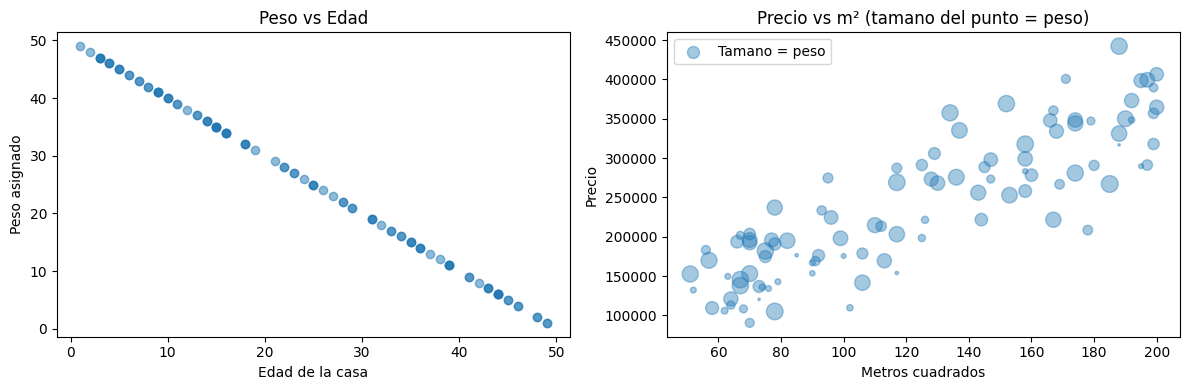

In [11]:
# Visualizar la distribucion de pesos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["age"], df["weight"], alpha=0.5)
axes[0].set_xlabel("Edad de la casa")
axes[0].set_ylabel("Peso asignado")
axes[0].set_title("Peso vs Edad")

sizes = df["weight"] * 3
axes[1].scatter(
    df["square_meters"], df["price"], s=sizes, alpha=0.4, label="Tamano = peso"
)
axes[1].set_xlabel("Metros cuadrados")
axes[1].set_ylabel("Precio")
axes[1].set_title("Precio vs m² (tamano del punto = peso)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. OLS sin pesos vs con pesos (statsmodels)

Comparemos los coeficientes del modelo estandar vs el ponderado usando `statsmodels.WLS` (Weighted Least Squares).

In [12]:
predictors = [
    "square_meters",
    "age",
    "bedrooms",
    "bathrooms",
    "distance_to_center_km",
    "build_quality",
]
target = "price"

X = df[predictors]
y = df[target]
X_const = sm.add_constant(X)

# Modelo sin pesos (OLS)
model_ols = sm.OLS(y, X_const).fit()

# Modelo con pesos (WLS)
model_wls = sm.WLS(y, X_const, weights=df["weight"].to_numpy()).fit()  # type: ignore[arg-type]

# Comparar coeficientes
comparison = pd.DataFrame(
    {
        "OLS (sin pesos)": model_ols.params.round(2),
        "WLS (con pesos)": model_wls.params.round(2),
        "Diferencia %": (
            ((model_wls.params - model_ols.params) / model_ols.params) * 100
        ).round(2),
    }
)
print("Comparacion de coeficientes:")
print(comparison)

Comparacion de coeficientes:
                       OLS (sin pesos)  WLS (con pesos)  Diferencia %
const                         56460.85         62599.65         10.87
square_meters                  1043.03           866.78        -16.90
age                            -613.32          -287.47        -53.13
bedrooms                      10019.83         13196.03         31.70
bathrooms                     14782.81         19766.37         33.71
distance_to_center_km         -2496.04         -2629.66          5.35
build_quality                  5264.97          2742.20        -47.92


**Que observar:** Los coeficientes cambian porque el modelo ahora da mas importancia a las casas nuevas. Variables que se comportan diferente en casas nuevas vs viejas mostraran cambios mas grandes.

## 4. Weighted regression con scikit-learn

En `scikit-learn`, la mayoria de modelos aceptan pesos via `sample_weight` en el metodo `fit()`.

In [13]:
X = df[predictors].to_numpy()
y = df[target].to_numpy()
weights = df["weight"].to_numpy()

# Sin pesos
lr = LinearRegression()
lr.fit(X, y)

# Con pesos
lr_wt = LinearRegression()
lr_wt.fit(X, y, sample_weight=weights)

# Comparar
coef_df = pd.DataFrame(
    {
        "Variable": predictors,
        "Sin pesos": lr.coef_.round(2),
        "Con pesos": lr_wt.coef_.round(2),
    }
)
print(coef_df.to_string(index=False))
print(f"\nIntercept sin pesos: {lr.intercept_:.2f}")
print(f"Intercept con pesos: {lr_wt.intercept_:.2f}")

             Variable  Sin pesos  Con pesos
        square_meters    1043.03     866.78
                  age    -613.32    -287.47
             bedrooms   10019.83   13196.03
            bathrooms   14782.81   19766.37
distance_to_center_km   -2496.04   -2629.66
        build_quality    5264.97    2742.20

Intercept sin pesos: 56460.85
Intercept con pesos: 62599.65


## 5. Caso practico: Inverse-Variance Weighting

Cuando sabemos que ciertas observaciones tienen mas ruido (mayor varianza), les asignamos **menos peso**.

Simulemos un escenario donde casas en pisos altos tienen precios mas ruidosos (datos menos precisos).

In [15]:
# Simular: la varianza del precio aumenta con el piso
rng = np.random.default_rng(42)
noise_variance = df["floor"] * 5000  # mas piso = mas ruido
df["price_noisy"] = df["price"] + rng.normal(0, noise_variance)

# Peso = inverso de la varianza estimada
df["weight_iv"] = 1 / (df["floor"] + 1)  # +1 para evitar division por 0

# Modelo sin pesos vs con inverse-variance weights
X = df[predictors].to_numpy()
y_noisy = df["price_noisy"].to_numpy()

lr_no_wt = LinearRegression().fit(X, y_noisy)
lr_iv = LinearRegression().fit(X, y_noisy, sample_weight=df["weight_iv"].to_numpy())

# Comparar contra el modelo "verdadero" (sin ruido)
lr_true = LinearRegression().fit(X, df["price"].to_numpy())

coef_comp = pd.DataFrame(
    {
        "Variable": predictors,
        "Verdadero (sin ruido)": lr_true.coef_.round(2),
        "Sin pesos (con ruido)": lr_no_wt.coef_.round(2),
        "Inv-Variance (con ruido)": lr_iv.coef_.round(2),
    }
)
print("Comparacion de coeficientes:")
print(coef_comp.to_string(index=False))
print(
    "\n=> Los coeficientes con inverse-variance weighting se acercan mas a los verdaderos"
)

Comparacion de coeficientes:
             Variable  Verdadero (sin ruido)  Sin pesos (con ruido)  Inv-Variance (con ruido)
        square_meters                1043.03                 910.84                    892.83
                  age                -613.32               -1144.18                   -745.27
             bedrooms               10019.83                2290.08                   7920.92
            bathrooms               14782.81               27179.70                  24165.88
distance_to_center_km               -2496.04               -2568.98                  -2490.58
        build_quality                5264.97                4492.51                   4046.72

=> Los coeficientes con inverse-variance weighting se acercan mas a los verdaderos


## 6. Caso practico: Filas que representan multiples observaciones

A veces los datos vienen agregados: cada fila representa N observaciones. El peso indica cuantas.

In [ ]:
# Simular datos agregados por calidad de construccion
agg = (
    df.groupby("build_quality")
    .agg(
        price_mean=("price", "mean"),
        sqm_mean=("square_meters", "mean"),
        count=("price", "count"),
    )
    .reset_index()
)

print("Datos agregados (cada fila = grupo de casas):")
print(agg)

# Regresion sobre datos agregados SIN pesos (incorrecto)
lr_agg = LinearRegression()
lr_agg.fit(agg[["sqm_mean"]], agg["price_mean"])

# Regresion sobre datos agregados CON pesos (correcto)
lr_agg_wt = LinearRegression()
lr_agg_wt.fit(agg[["sqm_mean"]], agg["price_mean"], sample_weight=agg["count"])

# Regresion sobre datos individuales (referencia)
lr_ind = LinearRegression()
lr_ind.fit(df[["square_meters"]], df["price"])

print(f"\nCoeficiente (datos individuales):     {lr_ind.coef_[0]:.2f}")
print(f"Coeficiente (agregado SIN pesos):      {lr_agg.coef_[0]:.2f}")
print(f"Coeficiente (agregado CON pesos):      {lr_agg_wt.coef_[0]:.2f}")
print("\n=> Con pesos, el resultado del agregado se acerca al de datos individuales")

## 7. Impacto visual: como los pesos cambian la recta

Veamos graficamente como los pesos modifican la linea de regresion.

In [ ]:
X_simple = df[["square_meters"]].to_numpy()
y_simple = df["price"].to_numpy()
w = df["weight"].to_numpy()

# Ajustar ambos modelos
lr_std = LinearRegression().fit(X_simple, y_simple)
lr_wtd = LinearRegression().fit(X_simple, y_simple, sample_weight=w)

# Predicciones
x_range = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_std = lr_std.predict(x_range)
y_wtd = lr_wtd.predict(x_range)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    df["square_meters"],
    df["price"],
    c=df["weight"],
    cmap="YlOrRd",
    alpha=0.6,
    edgecolors="gray",
    s=60,
)
ax.plot(x_range, y_std, "b--", linewidth=2, label="OLS (sin pesos)")
ax.plot(x_range, y_wtd, "r-", linewidth=2, label="WLS (con pesos)")
ax.set_xlabel("Metros cuadrados")
ax.set_ylabel("Precio")
ax.set_title("Efecto de los pesos en la linea de regresion")
ax.legend()
plt.colorbar(scatter, label="Peso (mas claro = mas peso)")
plt.tight_layout()
plt.show()

print(f"Pendiente OLS: {lr_std.coef_[0]:.2f}")
print(f"Pendiente WLS: {lr_wtd.coef_[0]:.2f}")

## 8. Resumen - Key Ideas

| Concepto | Descripcion |
|----------|-------------|
| **Weighted Regression** | Asigna pesos a cada observacion para darle mas o menos influencia |
| **Minimiza** | $\sum w_i (y_i - \hat{y}_i)^2$ en lugar de $\sum (y_i - \hat{y}_i)^2$ |
| **Inverse-variance** | Peso = $1/\sigma^2_i$. Observaciones con mas ruido pesan menos |
| **Filas agregadas** | Peso = cantidad de observaciones que la fila representa |
| **statsmodels** | Usa `sm.WLS(y, X, weights=w)` |
| **scikit-learn** | Usa `model.fit(X, y, sample_weight=w)` |
| **Importante** | Los pesos no cambian el modelo dramaticamente, pero ajustan los coeficientes para reflejar la confiabilidad relativa de los datos |